# MNIST 데이터셋을 이용한 MLP 구현

In [1]:
import numpy as np

* MNIST 데이터 이해 - 분류문제 인지 확인
* Numpy에 대한 이해
* 활성함수 numpy 구현
* 퍼셉트론 구현
* 손실함수 구현
* 역전파 방법 구현
* MLP 구현

## 데이터셋 이해

MNIST 데이터셋<br></br>
손글씨 데이터셋으로 28x28 픽셀 이미지 데이터로 이루어져 있다.<br>
keras와 tensorflow가 load_mnist() 함수로 제공해주는 데이터의 형태가 다르고 load_mnist()가 return 해주는 값의 개수도 다르다.<br>
</br>
**keras** <br>
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()<br>
keras에서 제공하는 MNIST 데이터는 train 60,000개 test 10,000개로 되어있으며 이미지의 shape는 28x28이다.<br>
픽셀값은 0~255이며 정규화가 이루어지지 않은 형태이다.<br>
label 데이터는 어떤 숫자인지 나타낸다.
</br>

**tensorflow** <br>
from tensorflow.examples.tutorials.mnist import input_data<br>
mnist = input_data.read_data_sets()<br>
train 55,000개 val 5,000개 test 10,000개로 이루어져 있으며 이미지의 shape는 784이다. 이는 28x28 2차원 배열을 1차원의 형태로 변형한 것이다.<br>
픽셀값은 0~1 정규화가 이루어진 형태이고 label 데이터는 one-hot encoding이 적용되었다.

In [2]:
import tensorflow as tf
# import keras

#### kears - MNIST

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [5]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
y_train[0]

5

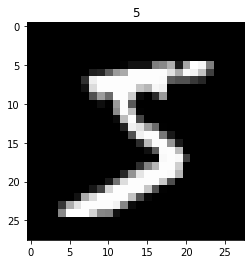

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap = 'gray')
plt.title(y_train[0])
plt.show()

#### tensorflow - MNIST

In [8]:
tf.__version__

'2.4.1'

In [9]:
# from tensorflow.examples.tutorials.mnist import input_data
# mnist = input_data.read_data_sets()

colab에서 examples 모듈은 더이상 이용되지 않는다고 한다,,

## MNIST 데이터 로드 후 파악

In [10]:
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [11]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [12]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [13]:
X_train[0].shape

(28, 28)

## Numpy 이해 (행렬 연산)

numpy의 행렬 곱은 행렬의 형상이 맞을 때 연산이 이루어 진다.<br>
A X B = C
3x2 X 2x4 = 3x4 처럼 A행렬의 열값과 B행렬의 행값이 일치해야 행렬 곱 연산이 수행되는 것이다.

In [14]:
A = np.array([[1,2,3],[2,3,4]]) # 2x3
A

array([[1, 2, 3],
       [2, 3, 4]])

In [15]:
B = np.ones(3,) # 3x1
B

array([1., 1., 1.])

In [16]:
C = np.matmul(A,B)
C

array([6., 9.])

In [17]:
C.shape # 2x1

(2,)

In [18]:
a = np.array([[1,2,3],[2,3,4]])
b = np.array([[1,2],[1,2],[1,2]])
c = np.matmul(a,b)
c

array([[ 6, 12],
       [ 9, 18]])

In [19]:
a_t = np.matmul(c, b.T)
a_t

array([[30, 30, 30],
       [45, 45, 45]])

In [20]:
D = A + B

In [21]:
D.shape

(2, 3)

## numpy 이해 (activation function 적용)



In [22]:
a = np.array([[10,11,19,17], [13, 12, 18, 15]])
print(a.shape)

def softmax(a):
    exp_a = np.exp(a)
    exp_a_sum = np.sum(exp_a)
    y = exp_a / exp_a_sum
    return y

y = softmax(a)
print(y)
print(y.shape)

(2, 4)
[[8.09043088e-05 2.19920713e-04 6.55574405e-01 8.87223477e-02]
 [1.62500648e-03 5.97806477e-04 2.41172346e-01 1.20072641e-02]]
(2, 4)


In [23]:
a = np.array([10,11,19,17])
print(a.shape)

def softmax(a):
    max_a = max(a)
    exp_a = np.exp(a-max_a)
    exp_a_sum = np.sum(exp_a)
    y = exp_a / exp_a_sum
    return y

y = softmax(a)
print(y)
print(y.shape)

(4,)
[1.08655079e-04 2.95355128e-04 8.80441227e-01 1.19154763e-01]
(4,)


In [24]:
def sigmoid(a):
    return 1 / (1+np.exp(-a))

y_sig = sigmoid(np.array(x_train[0]))
print(y_sig)
print(y_sig.shape)

[[5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01]
 [5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01]
 [5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01]
 [5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01
  5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01 5.000e-01

<ipython-input-24-4ff1b516edb1>:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1+np.exp(-a))


In [25]:
import numpy as np
w = np.array([[1,2,3],[4,5,6]])
print(np.sum(w))
print(np.sum(w, axis = 0))

21
[5 7 9]


## Numpy로 activation function 구현

In [26]:
# sigmoid

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [27]:
# relu
def relu(x):
    return np.maximum(0,x)

np.maximum은 여러 array를 동시에 input으로 받을 수 있다.<br>
input으로 받는 array의 차원은 같아야 하며 각 위치별로 최대값을 반환한다.<br>
np.maximum(0,x) 에서 0을 써준 이유는 x가 음수가 들어오는 경우 0을 최댓값으로 사용해주기 위함이다.<br>
cf) np.max는 단일 array 내의 최대값을 구함

In [50]:
# tanh

def tanh(x):
    return np.exp(x) - np.exp(-x) / np.exp(x) + np.exp(-x)

In [28]:
# softmax
def softmax(x):
    max_x = max(x)
    exp_x = np.exp(x - max_x)
    exp_x_sum = np.sum(exp_x)
    y = exp_x / exp_x_sum
    return y

softmax는 기본적으로 지수함수를 이용하기 때문에 input 값이 커지게 되면 exp 결과값이 기하급수적으로 증가하게 된다.<br>
이런 특성이 있기 때문에 input으로 들어오는 array값이 너무 크면 softmax의 exp 결과값이 무한대 값이 나와 overflow가 발생한다.<br>
이런 현상을 완화하기 위하여 x값에 최대값을 빼는 방식으로 진행한다. (지수함수 계산 시 어떤 수를 더하거나 빼도 결과에 변동이 없음) 

In [ ]:
# Mean square error

def mean_square_error(y, t):
    return np.sum(np.square(t - y)) / t.shape[0] / 2

In [29]:
# cross entropy loss
def cross_entropy_loss(y, t):
  delta = 1e-7
  return -np.sum(t * np.log(y+delta))

# MLP 구현

In [30]:
import numpy as np

## 데이터 로드

In [31]:
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

## 활성화 함수 구현

In [32]:
# 활성화 함수 sigmoid, relu, softmax
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0,x)

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis = 0)
        # 열 단위로 연산을 수행하기 위해 axis = 0 사용 - 이미지 하나의 max값 구해주기 위함
        y = np.exp(x) / np.sum(np.exp(x), axis = 0)
        return y.T

    x = x - np.max(x)
    return np.exp(x) / np.sum(np.exp(x))

## 손실함수 구현

In [33]:
# Cross entropy error
def cross_entropy_error(y, t):
    if y.ndim == 1: # 라벨만 있는 경우
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)
        
    if t.size == y.size: # 원-핫인코딩 된 형태
        t = t.argmax(axis = 1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

In [34]:
# 기울기 구하기 위한 수치미분 계산 코드
def numerical_gradient(f, x):
    h = 1e-4
    grads = np.zeros_like(x)
        
    for idx in range(x.size):
      tmp_val = x[idx]
      x[idx] = tmp_val + h
      fxh1 = f(x)

      x[idx] = tmp_val - h
      fxh2 = f(x)

      grads[idx] = (fxh1 - fxh2) / (2*h)
      x[idx] = tmp_val

    return grads

## 역전파 구현

오차역전파를 위한 활성화함수 layer - ReLU, sigmoid

In [35]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0
        return out
    
    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout
        return dx

In [36]:
class Sigmoid:
    def __init__(self):
        self.y = None

    def forward(self, x):
        y = sigmoid(x)
        self.y = y
        return y

    def backward(self, dout):
        dx = dout * self.y * (1 - self.y)
        return dx

행렬 곱 layer

In [37]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b

        self.x = None
        self.original_x_shape = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        y = np.matmul(self.x, self.W) + self.b
        return y

    def backward(self, dout):
        dx = np.matmul(dout, self.W.T)
        self.dW = np.matmul(self.x.T, dout)
        self.db = np.sum(dout, axis = 0)

        dx = dx.reshape(*self.original_x_shape)

        return dx

softmax + loss(Cross entropy error)

In [38]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.t = None
        self.y = None

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout = 1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size

        return dx

## 신경망 클래스

In [39]:
from collections import OrderedDict  # 디렉토리에 들어가는 순서를 기억(역전파 때 거꾸로 layer를 찾아야해서)

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        self.params = {}
        self.params['W1'] = np.random.randn(input_size, hidden_size) * weight_init_std
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = np.random.randn(hidden_size, output_size) * weight_init_std
        self.params['b2'] = np.zeros(output_size)

        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])
        self.lastlayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x)
        loss = self.lastlayer.forward(y, t)
        return loss

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis = 1)
        if t.ndim != 1: t = np.argmax(t, axis = 1)

        acc = np.sum(y == t) / float(y.shape[0])
        return acc

    def gradient(self, x, t):
        self.loss(x, t)

        dout = 1
        dout = self.lastlayer.backward(dout) # 역전파
        
        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        grads = {}
        grads['W1'] = self.layers['Affine1'].dW
        grads['b1'] = self.layers['Affine1'].db
        grads['W2'] = self.layers['Affine2'].dW
        grads['b2'] = self.layers['Affine2'].db

        return grads

    def numerical_gradient(self, x, t):
        loss_w = lambda w:self.loss(x, t)

        grads = {}

        grads['W1'] = numerical_gradient(loss_w, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_w, self.parmas['b1'])
        grads['W2'] = numerical_gradient(loss_w, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_w, self.params['b2'])

        return grads

## MNIST 데이터 학습

In [40]:
import tensorflow as tf

In [41]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
# normalize, one_hot_label 수행

In [42]:
# 데이터 정규화
X_train_n = X_train / 255.0
X_test_n = X_test / 255.0

In [43]:
X_train_n[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [56]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [44]:
# 데이터 1차원으로 shape 변형
X_train_r = X_train_n.reshape(-1, 784)
X_test_r = X_test_n.reshape(-1, 784)

In [45]:
X_train_r[0].shape

(784,)

In [46]:
def one_hot_encoding(x):
    T = np.zeros((x.size, 10))
    for idx, row in enumerate(T):
        row[x[idx]] = 1

    return T

In [47]:
# 라벨데이터 원핫인코딩
y_train_n = one_hot_encoding(y_train)
y_test_n = one_hot_encoding(y_test)

In [48]:
y_train_n[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [49]:
network = TwoLayerNet(input_size = 28*28, hidden_size = 50, output_size = 10)

steps = 1000
train_size = X_train_r.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss = []
train_acc = []
test_acc = []

for i in range(steps):
    batch_mask = np.random.choice(train_size, batch_size)
    X_batch = X_train_r[batch_mask]
    y_batch = y_train_n[batch_mask]

    grads = network.gradient(X_batch, y_batch)

    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grads[key]

    loss = network.loss(X_batch, y_batch)
    train_loss.append(loss)

    if i % 10 == 0:
        tr_acc = network.accuracy(X_batch, y_batch)
        te_acc = network.accuracy(X_test_r, y_test_n)
        train_acc.append(tr_acc)
        test_acc.append(te_acc)
        print(f'{i+1}번째 학습 후 Train Acc:', round(tr_acc, 3))
        print(f'{i+1}번째 학습 후 Test Acc:', round(te_acc, 3))
        print()

1번째 학습 후 Train Acc: 0.23
1번째 학습 후 Test Acc: 0.105

11번째 학습 후 Train Acc: 0.2
11번째 학습 후 Test Acc: 0.227

21번째 학습 후 Train Acc: 0.26
21번째 학습 후 Test Acc: 0.258

31번째 학습 후 Train Acc: 0.46
31번째 학습 후 Test Acc: 0.446

41번째 학습 후 Train Acc: 0.4
41번째 학습 후 Test Acc: 0.433

51번째 학습 후 Train Acc: 0.34
51번째 학습 후 Test Acc: 0.393

61번째 학습 후 Train Acc: 0.51
61번째 학습 후 Test Acc: 0.474

71번째 학습 후 Train Acc: 0.59
71번째 학습 후 Test Acc: 0.558

81번째 학습 후 Train Acc: 0.67
81번째 학습 후 Test Acc: 0.628

91번째 학습 후 Train Acc: 0.62
91번째 학습 후 Test Acc: 0.663

101번째 학습 후 Train Acc: 0.73
101번째 학습 후 Test Acc: 0.735

111번째 학습 후 Train Acc: 0.79
111번째 학습 후 Test Acc: 0.779

121번째 학습 후 Train Acc: 0.77
121번째 학습 후 Test Acc: 0.791

131번째 학습 후 Train Acc: 0.91
131번째 학습 후 Test Acc: 0.812

141번째 학습 후 Train Acc: 0.78
141번째 학습 후 Test Acc: 0.814

151번째 학습 후 Train Acc: 0.85
151번째 학습 후 Test Acc: 0.826

161번째 학습 후 Train Acc: 0.84
161번째 학습 후 Test Acc: 0.826

171번째 학습 후 Train Acc: 0.86
171번째 학습 후 Test Acc: 0.842

181번째 학습 후 Train Acc: 0.88
181번째 학